# Loan Approval Prediction Model

By Jompe Emmanuel Ayomiposi, Level 3 Artificial Intelligence Project

The Machine Learning Approach used is Supervised Classification 

Supervised: It learns from data in a dataset

Classification: The label (Loan Approved), is discrete; either True or False

In [1]:
# Import Required Libraries


import pandas as pd                          
import numpy as np                           
import matplotlib.pyplot as plt              
import seaborn as sns                        
import warnings                              

from sklearn.model_selection import train_test_split        
from sklearn.ensemble import RandomForestClassifier         
from sklearn.metrics import (
    accuracy_score,          
    classification_report,   
    confusion_matrix         
)
import joblib                                              

warnings.filterwarnings('ignore')   

print(" Libraries imported successfully")

 Libraries imported successfully


In [2]:
# Load the Dataset

df = pd.read_csv('loan_approval.csv')


print(" First 5 rows of the dataset:")
print(df.head())

print(f"\n Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\n Column Data Types:")
print(df.dtypes)

 First 5 rows of the dataset:
              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27    50.0          False  
1              28    55.0          False  
2              13    45.0          False  
3              29    50.0          False  
4               4    25.0          False  

 Dataset Shape: 2000 rows x 8 columns

 Column Data Types:
name               object
city               object
income              int64
credit_score        int64
loan_amount         int64
years_employed      int64
points            float64
loan_approved      

In [3]:
# Exploratory Data Analysis (EDA)

print(" Statistical Summary:")
print(df.describe())

print("\n Missing Values per Column:")
print(df.isnull().sum())

approval_counts = df['loan_approved'].value_counts()
approval_pct = df['loan_approved'].value_counts(normalize=True) * 100
print("\n Loan Approval Distribution:")
print(f"   Approved (True)  : {approval_counts.get(True, 0):>5} records ({approval_pct.get(True, 0):.1f}%)")
print(f"   Denied   (False) : {approval_counts.get(False, 0):>5} records ({approval_pct.get(False, 0):.1f}%)")

 Statistical Summary:
              income  credit_score   loan_amount  years_employed       points
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000
mean    90585.977000    573.946000  25308.503000       20.441000    56.680000
std     34487.874907    160.564945  14207.320147       11.777813    18.638033
min     30053.000000    300.000000   1022.000000        0.000000    10.000000
25%     61296.250000    433.000000  12748.750000       10.000000    45.000000
50%     90387.500000    576.000000  25661.500000       21.000000    55.000000
75%    120099.750000    715.000000  37380.500000       31.000000    70.000000
max    149964.000000    850.000000  49999.000000       40.000000   100.000000

 Missing Values per Column:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

 Loan Approval Distribution:
   Approved (True)  :   879 records (44.0%)


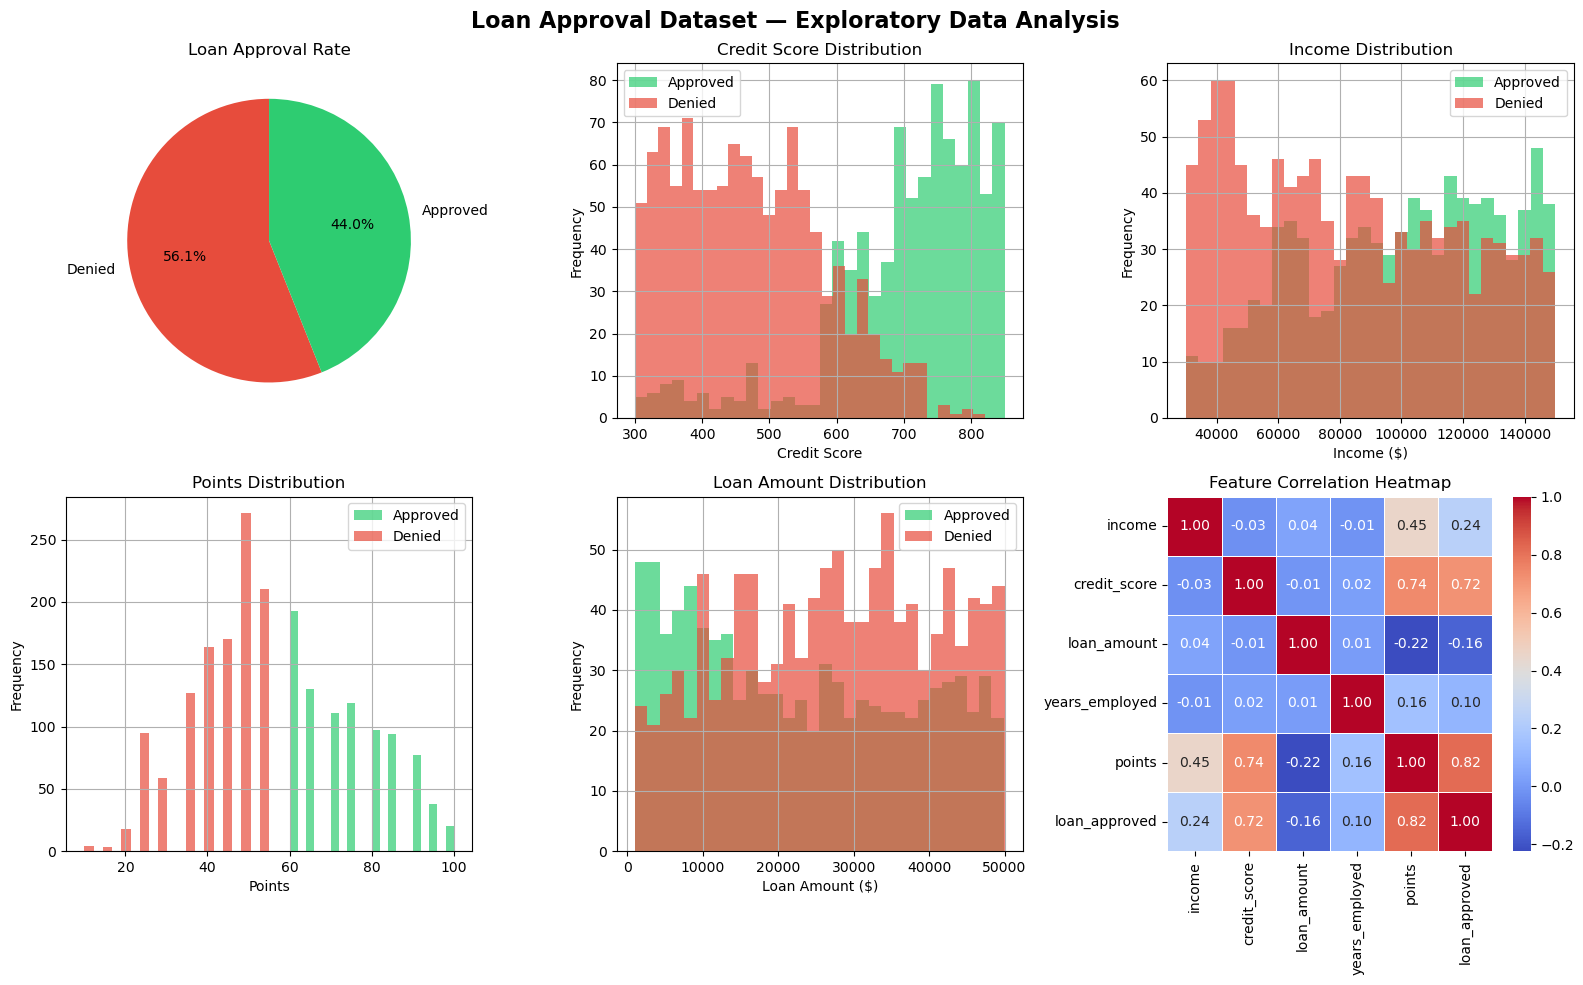

 EDA plots saved as eda_loan_approver.png


In [4]:
# Visualizations


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Loan Approval Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1: Loan Approval Rate (Pie Chart)
approval_counts = df['loan_approved'].value_counts()
axes[0, 0].pie(
    approval_counts.values,
    labels=['Denied', 'Approved'],
    colors=['#e74c3c', '#2ecc71'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0, 0].set_title('Loan Approval Rate')

# Plot 2: Credit Score Distribution by Approval Status
df[df['loan_approved'] == True]['credit_score'].hist(ax=axes[0, 1], bins=30, alpha=0.7, color='#2ecc71', label='Approved')
df[df['loan_approved'] == False]['credit_score'].hist(ax=axes[0, 1], bins=30, alpha=0.7, color='#e74c3c', label='Denied')
axes[0, 1].set_title('Credit Score Distribution')
axes[0, 1].set_xlabel('Credit Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Plot 3: Income Distribution by Approval Status
df[df['loan_approved'] == True]['income'].hist(ax=axes[0, 2], bins=30, alpha=0.7, color='#2ecc71', label='Approved')
df[df['loan_approved'] == False]['income'].hist(ax=axes[0, 2], bins=30, alpha=0.7, color='#e74c3c', label='Denied')
axes[0, 2].set_title('Income Distribution')
axes[0, 2].set_xlabel('Income ($)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()

# Plot 4: Points Distribution
df[df['loan_approved'] == True]['points'].hist(ax=axes[1, 0], bins=20, alpha=0.7, color='#2ecc71', label='Approved')
df[df['loan_approved'] == False]['points'].hist(ax=axes[1, 0], bins=20, alpha=0.7, color='#e74c3c', label='Denied')
axes[1, 0].set_title('Points Distribution')
axes[1, 0].set_xlabel('Points')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 5: Loan Amount Distribution
df[df['loan_approved'] == True]['loan_amount'].hist(ax=axes[1, 1], bins=30, alpha=0.7, color='#2ecc71', label='Approved')
df[df['loan_approved'] == False]['loan_amount'].hist(ax=axes[1, 1], bins=30, alpha=0.7, color='#e74c3c', label='Denied')
axes[1, 1].set_title('Loan Amount Distribution')
axes[1, 1].set_xlabel('Loan Amount ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

# Plot 6: Correlation Heatmap (numeric features only)
numeric_df = df.select_dtypes(include=np.number)
numeric_df['loan_approved'] = df['loan_approved'].astype(int)
corr = numeric_df.corr()
sns.heatmap(corr, ax=axes[1, 2], annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
axes[1, 2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_loan_approver.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots saved as eda_loan_approver.png")

In [5]:
# Data Cleaning & Preprocessing

'''
We prepare the dataset by:
 • Dropping columns that are NOT predictive (name, city)
 • Converting the boolean target to integer (True→1, False→0)
 • Checking for and handling any remaining null values
'''

columns_to_drop = ['name', 'city']
df.drop(columns=columns_to_drop, inplace=True)
print(f" Dropped columns: {columns_to_drop}")


df['loan_approved'] = df['loan_approved'].astype(int)
print(" Converted 'loan_approved' boolean → integer (True=1, False=0)")

# Handling missing values 
null_count = df.isnull().sum().sum()
if null_count > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)
    print(f" Filled {null_count} missing values with column medians")
else:
    print(" No missing values found — dataset is clean")

print(f"\n Cleaned dataset shape: {df.shape}")
print(df.head())

 Dropped columns: ['name', 'city']
 Converted 'loan_approved' boolean → integer (True=1, False=0)
 No missing values found — dataset is clean

 Cleaned dataset shape: (2000, 6)
   income  credit_score  loan_amount  years_employed  points  loan_approved
0  113810           389        39698              27    50.0              0
1   44592           729        15446              28    55.0              0
2   33278           584        11189              13    45.0              0
3  127196           344        48823              29    50.0              0
4   66048           496        47174               4    25.0              0


In [6]:
# Feature Engineering & Dataset Split

'''
Features (X) — all numeric columns except target:
 income, credit_score, loan_amount, years_employed, points

Target (y):
 loan_approved  →  1 (Approved) or 0 (Denied)

Then split the data into training (80%) and testing (20%) sets.
'''


# Define features and target
X = df.drop(columns=['loan_approved'])   
y = df['loan_approved']                 

print(f" Features: {list(X.columns)}")
print(f" Feature matrix shape: {X.shape}")
print(f" Target vector shape : {y.shape}")

# Split into training and testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      
    random_state=42,     
    stratify=y           
)

print("\n Data split complete:")
print(f" Training samples : {X_train.shape[0]}")
print(f" Testing samples  : {X_test.shape[0]}")
print(f" Approval rate (train): {y_train.mean()*100:.1f}%")
print(f" Approval rate (test) : {y_test.mean()*100:.1f}%")

 Features: ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
 Feature matrix shape: (2000, 5)
 Target vector shape : (2000,)

 Data split complete:
 Training samples : 1600
 Testing samples  : 400
 Approval rate (train): 43.9%
 Approval rate (test) : 44.0%


In [7]:
# Model Training (Random Forest Classifier)

classifier = RandomForestClassifier(
    n_estimators=200,    
    max_depth=None,      
    random_state=42,     
    n_jobs=-1            
)

print(" Training Random Forest Classifier...")
classifier.fit(X_train, y_train)
print(" Model training complete!")

 Training Random Forest Classifier...
 Model training complete!


In [9]:
# Model Evaluation

'''
We evaluate the classifier using:
 • Accuracy: overall correct prediction rate
 • Precision: of predicted Approved, how many were truly Approved
 • Recall: of actual Approved, how many did we catch
 • F1-Score: harmonic mean of precision and recall
 • Confusion Matrix: True/False Positive & Negative breakdown
'''

# Generate class predictions on the test set
y_pred = classifier.predict(X_test)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print("_" * 55)
print("        MODEL EVALUATION RESULTS")
print("_" * 55)
print(f"  Overall Accuracy : {accuracy * 100:.2f}%")
print("_" * 55)
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Denied (0)', 'Approved (1)']))

# Simple performance interpretation
if accuracy >= 0.90:
    print(" Excellent model accuracy! (≥ 90%)")
elif accuracy >= 0.80:
    print(" Good model accuracy! (≥ 80%)")
elif accuracy >= 0.70:
    print("  Moderate model accuracy.")
else:
    print(" Weak accuracy — consider feature engineering.")

_______________________________________________________
        MODEL EVALUATION RESULTS
_______________________________________________________
  Overall Accuracy : 100.00%
_______________________________________________________

 Classification Report:
              precision    recall  f1-score   support

  Denied (0)       1.00      1.00      1.00       224
Approved (1)       1.00      1.00      1.00       176

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

 Excellent model accuracy! (≥ 90%)


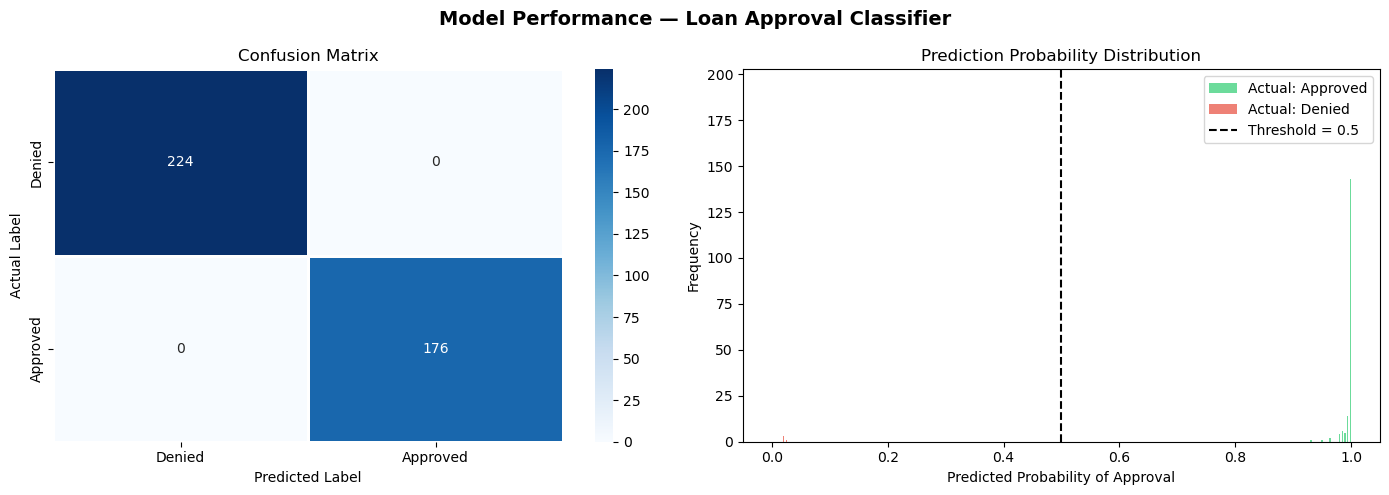

 Performance plots saved as model_performance_loan_approver.png


In [10]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance — Loan Approval Classifier', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Denied', 'Approved'],
    yticklabels=['Denied', 'Approved'],
    linewidths=1
)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')
axes[0].set_title('Confusion Matrix')

# Plot 2: Prediction probability distribution
proba = classifier.predict_proba(X_test)[:, 1]   # Probability of Approved
axes[1].hist(proba[y_test == 1], bins=30, alpha=0.7, color='#2ecc71', label='Actual: Approved')
axes[1].hist(proba[y_test == 0], bins=30, alpha=0.7, color='#e74c3c', label='Actual: Denied')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability of Approval')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Prediction Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_performance_loan_approver.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Performance plots saved as model_performance_loan_approver.png")

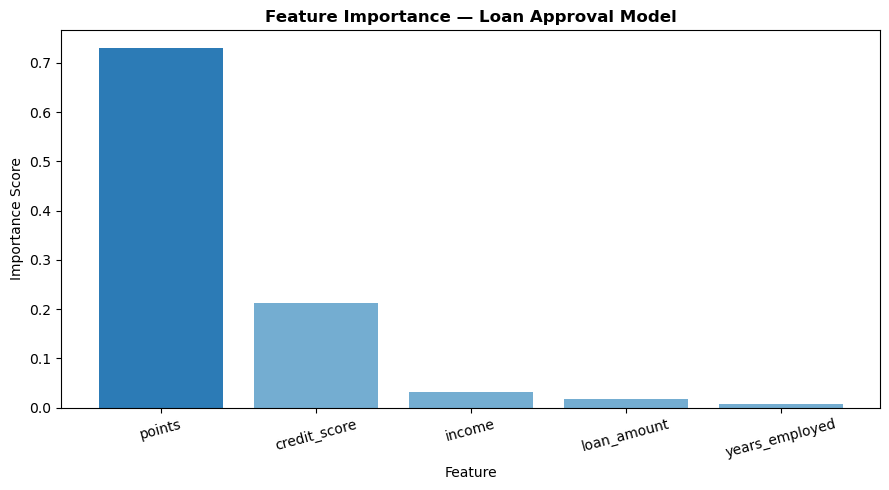


 Feature Importance Ranking:
   points             : 0.7297
   credit_score       : 0.2126
   income             : 0.0319
   loan_amount        : 0.0178
   years_employed     : 0.0080


In [11]:
# Feature Importance

# Extract feature importances from trained classifier
importances = classifier.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance descending
sorted_idx = np.argsort(importances)[::-1]

# Bar chart of feature importances
plt.figure(figsize=(9, 5))
bar_colors = ['#2c7bb6' if i == 0 else '#74add1' for i in range(len(feature_names))]
plt.bar(
    [feature_names[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color=bar_colors
)
plt.title('Feature Importance — Loan Approval Model', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('feature_importance_loan_approver.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking:")
for i in sorted_idx:
    print(f"   {feature_names[i]:<18} : {importances[i]:.4f}")

In [12]:
# Saving the Trained Model

import os

# Save the trained classification model
model_path = 'loan_approver_model.pkl'
joblib.dump(classifier, model_path)
print(f" Model saved to: {os.path.abspath(model_path)}")

# Also save the feature column order so Django uses the correct input shape
feature_order_path = 'loan_features.pkl'
joblib.dump(list(X.columns), feature_order_path)
print(f" Feature order saved to: {os.path.abspath(feature_order_path)}")

print("\n Loan Approval Classification Model is ready for deployment!")

 Model saved to: c:\Users\HP\Desktop\Work\SQI Course\SQI-Ai\Level 3 ML Project\Loan Approver\loan_approver_model.pkl
 Feature order saved to: c:\Users\HP\Desktop\Work\SQI Course\SQI-Ai\Level 3 ML Project\Loan Approver\loan_features.pkl

 Loan Approval Classification Model is ready for deployment!


In [13]:
# Quick Prediction Demo

# Load the saved model
loaded_classifier = joblib.load('loan_approver_model.pkl')

# ── Sample loan application ───────────────────────────────────────────────────
sample_application = pd.DataFrame({
    'income'         : [85000],    
    'credit_score'   : [720],      
    'loan_amount'    : [25000],    
    'years_employed' : [5],        
    'points'         : [75]        
})

# Predict class and probability
prediction   = loaded_classifier.predict(sample_application)[0]
probability  = loaded_classifier.predict_proba(sample_application)[0]

result_label = 'APPROVED' if prediction == 1 else 'DENIED'

print("  Loan Application Demo")
print("─" * 40)
print(f"  Income          : ${sample_application['income'][0]:,}")
print(f"  Credit Score    : {sample_application['credit_score'][0]}")
print(f"  Loan Amount     : ${sample_application['loan_amount'][0]:,}")
print(f"  Years Employed  : {sample_application['years_employed'][0]}")
print(f"  Points          : {sample_application['points'][0]}")
print("─" * 40)
print(f"  Decision        : {result_label}")
print(f"  Confidence      : {max(probability)*100:.1f}%")
print(f"  P(Denied)       : {probability[0]*100:.1f}%")
print(f"  P(Approved)     : {probability[1]*100:.1f}%")

  Loan Application Demo
────────────────────────────────────────
  Income          : $85,000
  Credit Score    : 720
  Loan Amount     : $25,000
  Years Employed  : 5
  Points          : 75
────────────────────────────────────────
  Decision        : APPROVED
  Confidence      : 100.0%
  P(Denied)       : 0.0%
  P(Approved)     : 100.0%
